# Predicción con Modelo ARIMA en series temporales
## Paso 1: Modelo ARIMA

Un modelo ARIMA combina tres componentes: **Autoregresivo (AR)**, **Diferenciación (I)** y **Media Móvil (MA)**. Su ecuación general es:

$$
Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \ldots + \phi_p Y_{t-p} + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \ldots + \theta_q \varepsilon_{t-q} + \varepsilon_t
$$

Donde:
- $Y_t$: Valor actual de la serie.
- $p$: Orden de la parte autoregresiva (AR).
- $d$: Diferenciación para hacer la serie estacionaria.
- $q$: Orden de la media móvil (MA).
- $c$: Constante.
- $\phi_i$: Coeficientes AR.
- $\theta_i$: Coeficientes MA.
- $\varepsilon_t$: Error aleatorio en el tiempo $t$.

## Paso 2: Evaluar la Estacionariedad

Para ajustar un modelo ARIMA, primero evaluamos si la serie es estacionaria (media y varianza constantes). Si no lo es, aplicamos diferenciación.

Prueba de estacionariedad:

- Prueba **Dickey-Fuller aumentada (ADF)**:

$$
H_0: \text{La serie no es estacionaria.}
$$

$$
H_1: \text{La serie es estacionaria.}
$$

Si el valor p es menor que 0.05, rechazamos $H_0$.

## Paso 3: Identificar Parámetros $(p, d, q)$

- **Autocorrelación (ACF)**: Para identificar $q$.
- **Autocorrelación parcial (PACF)**: Para identificar $p$.
- **Diferenciación ($d$)**: Determinar si la serie necesita diferencias para hacerse estacionaria.

## Paso 4: Evaluar el Modelo con AIC y BIC

- **AIC (Criterio de Información de Akaike):**

$$
AIC = -2 \ln(L) + 2k
$$

- **BIC (Criterio de Información Bayesiana):**

$$
BIC = -2 \ln(L) + k \ln(n)
$$

Donde:
- $L$: Verosimilitud del modelo.
- $k$: Número de parámetros.
- $n$: Número de observaciones.

El modelo con los valores más bajos de AIC y BIC es preferido.

## Paso 5: Predicción

Con el modelo ajustado, hacemos la predicción para los próximos 3 meses:

$$
\hat{Y}_{t+h} = \text{Modelo ARIMA}(p, d, q)
$$

donde $h$ es el horizonte de predicción.

## Resultados Esperados

1. Determinar si la serie es estacionaria.  
2. Seleccionar los valores óptimos de $(p, d, q)$.  
3. Calcular los valores de AIC y BIC.  
4. Predecir los precios para los próximos 3 meses.  

[*********************100%***********************]  1 of 1 completed
/home/prantony/Documents/inv_unidad02/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


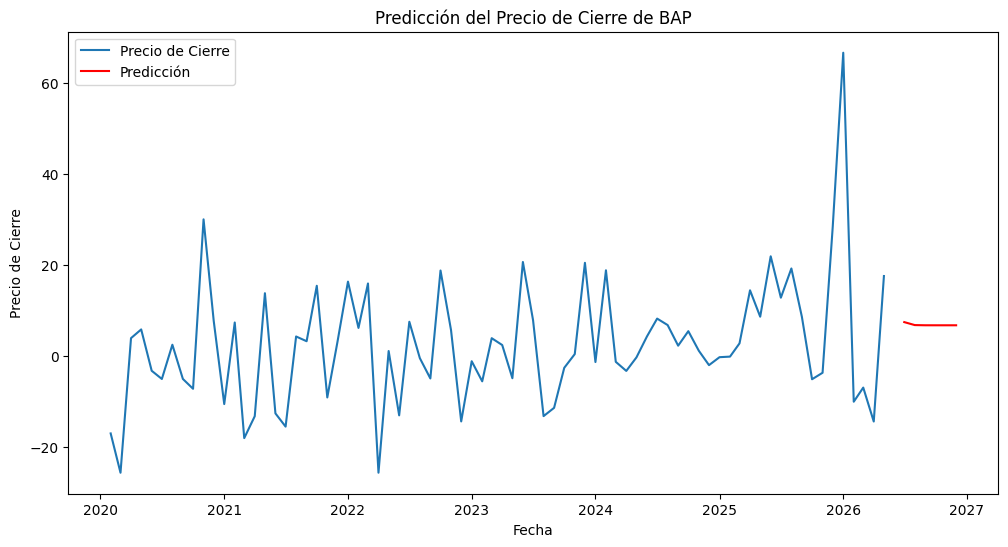

AIC: 615.0319932036125
BIC: 621.9844575442214
Predicción para los próximos 12 meses:
Mes 1: 7.505963805761791
Mes 2: 6.853527219541154
Mes 3: 6.811468225131913
Mes 4: 6.808756913338435
Mes 5: 6.8085821299955445
Mes 6: 6.808570862675782


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# datos 
ticker = "BAP"
START_DATE = "2020-01-01"
END_DATE = "2026-05-31"

data = yf.download(
    ticker, 
    start=START_DATE, 
    end=END_DATE,
    interval="1mo"
)

# Evaluar estacionariedad
adf_result = adfuller(data['Close'])
p_value = adf_result[1]

if p_value > 0.05:
    data['Close_diff'] = data['Close'].diff()
    data.dropna(inplace=True)
else:
    print("La serie es estacionaria.")
    
# Ajustar el modelo ARIMA
model = ARIMA(data['Close_diff'], order=(1, 1, 1))
model_fit = model.fit()

# Evaluar el modelo AIC y BIC
aic = model_fit.aic
bic = model_fit.bic

# prediccion para los próximos 12 meses
forecast_steps = 6
forecast = model_fit.forecast(steps=forecast_steps)

# Crear grafico de la serie original y la predicción
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close_diff'], label='Precio de Cierre')
plt.plot(pd.date_range(start=data.index[-1], periods=forecast_steps + 1, freq='ME')[1:], forecast, label='Predicción', color='red')
plt.title('Predicción del Precio de Cierre de BAP')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.legend()
plt.show()

# print resultados
print(f"AIC: {aic}")
print(f"BIC: {bic}")
print("Predicción para los próximos 12 meses:")
for i, value in enumerate(forecast):
    print(f"Mes {i + 1}: {value}")


